# Day 7 of Machine Learning Journey
### Polynomial Regression using Scikit-Learn

**Author:** Aneesh  
**Day:** 7   
**Topic:** Polynomial Regression


In this module, I focus on understanding how optimization algorithms work internally by implementing Gradient Descent techniques from scratch, applied to Polynomial Linear Regression.

Using a structured dataset with a non-linear relationship, I model the interaction between input features and the target variable by transforming the features into polynomial form and manually deriving the gradient update rules.

The objective is to deeply understand how a model learns from data through iterative optimization — specifically:

How polynomial features allow linear models to capture non-linear patterns


### Dataset Description

###Installing Libraries


In [4]:
pip install numpy pandas matplotlib scikit-learn

###Importing Libraries

In [26]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score , mean_squared_error

from sklearn.pipeline import Pipeline

## Feature and Target Selection


In [6]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)  # added some noise for real life

# y = 0.8x^2 + 0.9x + 2   this is the eq used here

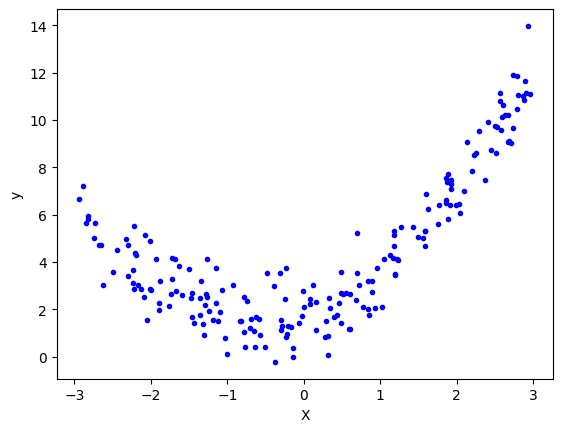

In [18]:
plt.plot(X, y,'b.' )
plt.xlabel("X")
plt.ylabel("y")
plt.show()

0.3470454922567189
mse 6.23966329985619


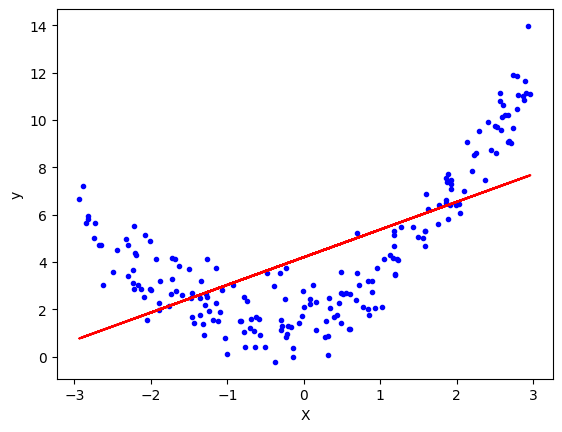

In [28]:
X_train , X_test, Y_train , Y_test = train_test_split(X,y,test_size = 0.2 , random_state = 13)

lr = LinearRegression()
lr.fit(X_train,Y_train)

predicted_values = lr.predict(X_test)

r2 = r2_score(Y_test , predicted_values)
print(r2)
print('mse', mean_squared_error(Y_test , predicted_values))

plt.plot(X, y,'b.' )
plt.plot(X_test,predicted_values , color = 'red')
plt.xlabel("X")
plt.ylabel("y")
plt.show()


In [33]:
# applying polynomial features only on input

poly = PolynomialFeatures(degree = 2 )

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

print(X_train[0])   # this is the original x_train
print(" ")
print(X_train_trans[0])   # this is the transformed x i.e the value of x _train for x ^0 , x^1 , x^2 ;

[-0.92360278]
 
[ 1.         -0.92360278  0.8530421 ]


In [41]:
lr = LinearRegression()
lr.fit(X_train_trans , Y_train)
y_pred = lr.predict(X_test_trans)

print(r2_score(Y_test , y_pred))

print(lr.coef_)
print(lr.intercept_)


0.9218480135074631
[[0.         0.95792009 0.83967641]]
[1.81315398]


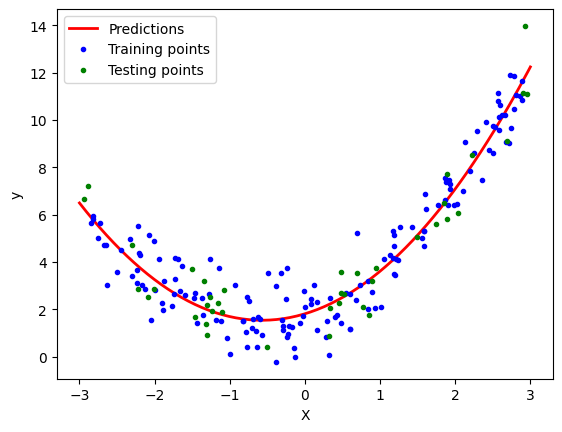

In [43]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, Y_train, "b.",label='Training points')
plt.plot(X_test, Y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

###Conclusion

In this notebook, I focused on implementing and understanding Polynomial Linear Regression to model non-linear relationships within the dataset.

What I accomplished:

Generated and analyzed a non-linear dataset

Transformed input features into polynomial form to capture quadratic patterns

Implemented Polynomial Regression to model the relationship between input and target variables

Trained the model and evaluated its performance using appropriate regression metrics

Visualized the fitted polynomial curve along with training and testing data points

Verified that the model successfully captured the underlying quadratic relationship

Through this implementation, I developed a clear understanding of how linear models can be extended using polynomial feature transformation to handle non-linear data patterns effectively.